# FASE 07. Análisis afectivo multimodal de llamadas

Este notebook unifica las antiguas fases **07, 07B y 07C** sin convertirlas en una caja negra:

1. **07A — sentimiento textual** sobre las transcripciones en español;
2. **07B — emoción acústica y prosodia** sobre los segmentos de audio;
3. **07C — fusión audio–texto**, concordancia y discordancias.

La lógica reutilizable permanece en tres módulos separados de `src/`, mientras que aquí se mantienen visibles la restauración, las decisiones de reutilización, los controles, las tablas, las figuras y la sincronización con GCS.

## 07.0 — Configuración del entorno

**Kernel requerido:** `Python (TFM_HuellaDeVoz)`

In [1]:
# Instalación acumulada del proyecto

from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
requirements_path = REPO_ROOT / "requirements.txt"

%pip install -q -r {requirements_path}

print("Requirements instalados desde:", requirements_path)

Note: you may need to restart the kernel to use updated packages.
Requirements instalados desde: /home/jupyter/TFM_ProcesadoDeAudios/requirements.txt


In [2]:
# IMPORTS

import sys
from pathlib import Path

from IPython.display import display
from google.cloud import storage
import matplotlib.pyplot as plt
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import (
    DATA_DIR,
    INPUT_DIR,
    FINAL_RELABEL_DIR,
    ALL_FINAL_MERGED_SEGMENTS_CSV,
    TRANSCRIPTION_ROOT,
    TRANSCRIPTION_ALL_SEGMENTS_CSV,
    TRANSCRIPTION_FINAL_SEGMENTS_CSV,
    PROXY_GROUNDTRUTH_DIR,
    PROXY_SEGMENT_LEVEL_CSV,
    GCS_UNAV_ROOT,
    GCS_CLEAN_AUDIO_PREFIX,
    HF_TOKEN,
    SENTIMENT_DIR,
    SENTIMENT_FIGURES_DIR,
    GCS_SENTIMENT_PREFIX,
    SEGMENTS_WITH_SENTIMENT_CSV,
    ALL_SEGMENTS_SENTIMENT_ENRICHED_CSV,
    CALL_SENTIMENT_CSV,
    CALL_ROLE_SENTIMENT_CSV,
    ROLE_SENTIMENT_CSV,
    SPEAKER_SENTIMENT_CSV,
    TEMPORAL_SENTIMENT_CSV,
    SENTIMENT_SUMMARY_CSV,
    SENTIMENT_CHECKPOINT_CSV,
    SENTIMENT_MODEL_NAME,
    PROSODY_DIR,
    GCS_PROSODY_PREFIX,
    SEGMENTS_PROSODY_CSV,
    CALL_PROSODY_CSV,
    CALL_ROLE_PROSODY_CSV,
    CALL_SPEAKER_PROSODY_CSV,
    ROLE_PROSODY_CSV,
    PROSODY_SUMMARY_CSV,
    SER_PREDICTIONS_CSV,
    AUDIO_TEXT_COMPARISON_CSV,
    SER_CHECKPOINT_CSV,
    PROSODY_FEATURES_CHECKPOINT_CSV,
    SER_MODEL_ID,
    SENTIMENT_FUSION_DIR,
    SENTIMENT_FUSION_FIGURES_DIR,
    GCS_SENTIMENT_FUSION_PREFIX,
    FUSION_SEGMENTS_CSV,
    FUSION_CORRELATIONS_CSV,
    FUSION_CONFUSION_CSV,
    FUSION_DISAGREEMENT_CSV,
    FUSION_ROLE_LEVEL_CSV,
    FUSION_CALL_LEVEL_CSV,
    FUSION_SUMMARY_CSV,
    ensure_phase07a_directories,
    ensure_phase07b_directories,
    ensure_phase07c_directories,
)
from src.storage_io import (
    download_directory,
    download_prefix_to_local,
    upload_directory,
)
from src import sentimiento_textual as st
from src import afectivo_audio as aa
from src import fusion_audio_texto as fat

print("Imports cargados correctamente.")

Imports cargados correctamente.


In [3]:
# CONEXIÓN A GOOGLE CLOUD STORAGE

gcs_client = storage.Client()
print("Cliente GCS creado para el proyecto:", gcs_client.project)

Cliente GCS creado para el proyecto: mm-bi-catedras-upm


In [4]:
# CONFIGURACIÓN DE EJECUCIÓN

# Recalcular obliga a reconstruir la fase desde sus inputs, pero conserva y reutiliza
# checkpoints válidos para no repetir inferencias ya completadas.
FORCE_RECALCULATE_07A = False
FORCE_RECALCULATE_SER = False
FORCE_RECALCULATE_PROSODY = False
FORCE_RECALCULATE_07C = False
FORCE_RESTORE_INPUTS = False

# Debug opcional. Mantener None para la ejecución final completa.
MAX_SEGMENTS_DEBUG = None

# Parámetros originales de 07A
MIN_WORDS_FOR_SENTIMENT = 2
SENTIMENT_BATCH_SIZE_GPU = 32
SENTIMENT_BATCH_SIZE_CPU = 8
SENTIMENT_MAX_LENGTH = 128

# Parámetros originales de 07B
TARGET_SAMPLE_RATE = 16000
FRAME_LENGTH = 1024
HOP_LENGTH = 256
FMIN = 50
FMAX = 500
MIN_SEGMENT_DURATION_SEC = 0.50
MAX_SEGMENT_DURATION_SEC = 30.0
MAX_OVERLAP_RATIO_PROSODY = 0.20
MIN_RMS_DBFS_INPUT = -45.0
REQUIRE_ROLE_PROXY = True
SER_SAVE_EVERY = 250
PROSODY_SAVE_EVERY_AUDIOS = 25
RUN_PRETRAINED_SER_MODEL = True

# Parámetros originales de 07C
AUDIO_HIGH_PERCENTILE = 75
TEXT_NONNEGATIVE_THRESHOLD = 0.0

ensure_phase07a_directories()
ensure_phase07b_directories()
ensure_phase07c_directories()

sentiment_paths = {
    "segments": SEGMENTS_WITH_SENTIMENT_CSV,
    "all_segments": ALL_SEGMENTS_SENTIMENT_ENRICHED_CSV,
    "call": CALL_SENTIMENT_CSV,
    "call_role": CALL_ROLE_SENTIMENT_CSV,
    "role": ROLE_SENTIMENT_CSV,
    "speaker": SPEAKER_SENTIMENT_CSV,
    "temporal": TEMPORAL_SENTIMENT_CSV,
    "summary": SENTIMENT_SUMMARY_CSV,
}
prosody_paths = {
    "segments": SEGMENTS_PROSODY_CSV,
    "call": CALL_PROSODY_CSV,
    "call_role": CALL_ROLE_PROSODY_CSV,
    "call_speaker": CALL_SPEAKER_PROSODY_CSV,
    "role": ROLE_PROSODY_CSV,
    "summary": PROSODY_SUMMARY_CSV,
    "ser": SER_PREDICTIONS_CSV,
    "comparison": AUDIO_TEXT_COMPARISON_CSV,
}
fusion_paths = {
    "segments": FUSION_SEGMENTS_CSV,
    "correlations": FUSION_CORRELATIONS_CSV,
    "confusion": FUSION_CONFUSION_CSV,
    "disagreement": FUSION_DISAGREEMENT_CSV,
    "role": FUSION_ROLE_LEVEL_CSV,
    "call": FUSION_CALL_LEVEL_CSV,
    "summary": FUSION_SUMMARY_CSV,
}

print("Configuración preparada. MAX_SEGMENTS_DEBUG =", MAX_SEGMENTS_DEBUG)

Configuración preparada. MAX_SEGMENTS_DEBUG = None


# 07A — Sentimiento textual

La fase usa las transcripciones de Whisper y los roles proxy de la fase 06. Primero intenta restaurar sus propios resultados; el modelo RoBERTuito solo se carga cuando quedan segmentos sin predicción en el checkpoint.

## 07A.1 — Restauración y decisión de ejecución

In [5]:
# Restaurar primero los outputs previos de la propia fase 07A.
restore_07a = download_directory(
    local_dir=SENTIMENT_DIR,
    gcs_prefix=GCS_UNAV_ROOT,
    gcs_client=gcs_client,
    base_dir=DATA_DIR,
)

sentiment_required_outputs = list(sentiment_paths.values())
sentiment_outputs_ready = (
    st.outputs_complete(sentiment_required_outputs)
    and not FORCE_RECALCULATE_07A
)

status_07a = pd.DataFrame(
    {
        "output": [path.name for path in sentiment_required_outputs],
        "exists": [path.exists() for path in sentiment_required_outputs],
        "size_bytes": [path.stat().st_size if path.exists() else 0 for path in sentiment_required_outputs],
    }
)
display(status_07a)
print("07A completa y reutilizable:", sentiment_outputs_ready)

Restauración desde GCS completada.
Archivos encontrados: 0
Archivos descargados: 0
Archivos locales ya vigentes: 0


,output,exists,size_bytes
0,segments_with_sentiment_textual.csv,True,47829246
1,all_segments_sentiment_textual_enriched.csv,True,52262150
2,call_level_sentiment_textual.csv,True,231127
3,call_role_level_sentiment_textual.csv,True,433417
4,role_level_sentiment_textual.csv,True,356
5,speaker_level_sentiment_textual.csv,True,404616
6,temporal_sentiment_textual.csv,True,795
7,sentiment_textual_summary_for_memory.csv,True,513


07A completa y reutilizable: True


In [6]:
# Los inputs pesados solo se restauran si 07A debe reconstruirse.
if not sentiment_outputs_ready:
    restore_transcription_07a = download_directory(
        local_dir=TRANSCRIPTION_ROOT,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )
    restore_proxy_07a = download_directory(
        local_dir=PROXY_GROUNDTRUTH_DIR,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )
    print("Inputs 07A restaurados.")
else:
    print("No se restauran transcripciones ni roles: los outputs finales 07A ya existen.")

No se restauran transcripciones ni roles: los outputs finales 07A ya existen.


## 07A.2 — Base textual y control previo

In [7]:
if sentiment_outputs_ready:
    loaded_07a = st.load_sentiment_outputs(sentiment_paths)
    df_sent = loaded_07a["segments"]
    df_all_enriched = loaded_07a["all_segments"]
    sentiment_aggregates = {
        "call_sentiment": loaded_07a["call"],
        "call_role_sentiment": loaded_07a["call_role"],
        "role_global_sentiment": loaded_07a["role"],
        "speaker_sentiment": loaded_07a["speaker"],
        "temporal_sentiment": loaded_07a["temporal"],
    }
    sentiment_summary = loaded_07a["summary"]
    df_base = df_all_enriched.copy()
    df_sent_input = df_sent.copy()
    sentiment_source = "outputs_07A_reutilizados"
    print("07A reutilizada sin cargar el modelo.")
else:
    transcription_candidates = [
        TRANSCRIPTION_FINAL_SEGMENTS_CSV,
        TRANSCRIPTION_ALL_SEGMENTS_CSV,
        TRANSCRIPTION_ROOT / "transcribed_segments_final.csv",
    ]
    df_base, df_sent_input, transcription_path = st.load_text_base(
        transcription_candidates=transcription_candidates,
        proxy_segment_csv=PROXY_SEGMENT_LEVEL_CSV,
        min_words_for_sentiment=MIN_WORDS_FOR_SENTIMENT,
    )
    quality_07a = st.build_quality_summary(df_base)
    sentiment_source = f"recalculado_desde_{transcription_path.name}"
    print("Transcripción seleccionada:", transcription_path)
    display(quality_07a)
    display(
        df_sent_input[
            [column for column in [
                "audio_file", "interval_mmss", "speaker_final", "role_proxy",
                "text_whisper", "n_words", "sentiment_uid"
            ] if column in df_sent_input.columns]
        ].head(10)
    )

print("Fuente 07A:", sentiment_source)
print("Segmentos disponibles para sentimiento:", len(df_sent_input))

07A reutilizada sin cargar el modelo.
Fuente 07A: outputs_07A_reutilizados
Segmentos disponibles para sentimiento: 36453


## 07A.3 — Inferencia textual con checkpoint

La comprobación del checkpoint se realiza antes de cargar RoBERTuito. Así, una VM nueva puede reconstruir los agregados sin volver a cargar el modelo si todas las predicciones segmentales ya estaban guardadas.

In [8]:
if not sentiment_outputs_ready:
    if SENTIMENT_CHECKPOINT_CSV.exists() and SENTIMENT_CHECKPOINT_CSV.stat().st_size > 0:
        sentiment_checkpoint = pd.read_csv(SENTIMENT_CHECKPOINT_CSV)
    else:
        sentiment_checkpoint = pd.DataFrame()

    completed_uids = (
        set(sentiment_checkpoint["sentiment_uid"].astype(str))
        if "sentiment_uid" in sentiment_checkpoint.columns
        else set()
    )
    pending_sentiment = df_sent_input[
        ~df_sent_input["sentiment_uid"].astype(str).isin(completed_uids)
    ].copy()

    print("Predicciones presentes en checkpoint:", len(completed_uids))
    print("Segmentos realmente pendientes:", len(pending_sentiment))

    if len(pending_sentiment) > 0:
        sentiment_pipeline, sentiment_batch_size, sentiment_device = st.load_sentiment_pipeline(
            model_name=SENTIMENT_MODEL_NAME,
            batch_size_gpu=SENTIMENT_BATCH_SIZE_GPU,
            batch_size_cpu=SENTIMENT_BATCH_SIZE_CPU,
        )
        print("Modelo textual cargado en:", sentiment_device)
        display(pd.DataFrame(sentiment_pipeline(
            ["La atención fue excelente.", "No me resolvieron el problema."],
            truncation=True,
            max_length=SENTIMENT_MAX_LENGTH,
        )))
        sentiment_checkpoint = st.apply_sentiment_with_checkpoint(
            df_sent_input=df_sent_input,
            sentiment_pipeline=sentiment_pipeline,
            batch_size=sentiment_batch_size,
            checkpoint_csv=SENTIMENT_CHECKPOINT_CSV,
            max_length=SENTIMENT_MAX_LENGTH,
        )
    else:
        print("Checkpoint completo: RoBERTuito no se carga.")
else:
    print("Outputs 07A completos: se omite toda inferencia textual.")

Outputs 07A completos: se omite toda inferencia textual.


## 07A.4 — Consolidación, agregados y guardado

In [9]:
if not sentiment_outputs_ready:
    df_sent, df_all_enriched = st.merge_sentiment_results(
        df_base=df_base,
        df_sent_input=df_sent_input,
        df_checkpoint=sentiment_checkpoint,
    )
    sentiment_aggregates = st.build_sentiment_aggregates(df_sent)
    sentiment_summary = st.build_summary_for_memory(
        df_base=df_base,
        df_sent=df_sent,
        call_sentiment=sentiment_aggregates["call_sentiment"],
        role_global_sentiment=sentiment_aggregates["role_global_sentiment"],
    )
    saved_07a = st.save_sentiment_outputs(
        df_sent=df_sent,
        df_all_enriched=df_all_enriched,
        aggregates=sentiment_aggregates,
        summary_for_memory=sentiment_summary,
        paths=sentiment_paths,
    )
    print("Outputs 07A guardados:", len(saved_07a))

sentiment_distribution = st.build_sentiment_distribution(df_sent)
display(sentiment_distribution)
display(sentiment_aggregates["role_global_sentiment"].round(4))
display(sentiment_aggregates["call_role_sentiment"].head(10))
display(sentiment_summary)

,sentiment_label,n_segments,percentage
0,neutral,26909,73.82
1,negative,6057,16.62
2,positive,3487,9.57


,role_proxy,n_segments,n_audios,total_words,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive
0,AGENT,19326,1166,307840,-0.034,0.7460,0.1229,0.7883,0.0888
1,CLIENT,16727,1166,198392,-0.111,0.7167,0.2149,0.6811,0.1040


,audio_file,audio_stem,role_proxy,n_segments,total_words,total_duration,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive,role_sentiment_label
0,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,AGENT,19,309,90.264375,-0.105263,0.727498,0.210526,0.684211,0.105263,neutral
1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,CLIENT,17,173,56.126250,0.000000,0.677426,0.176471,0.647059,0.176471,neutral
2,raw_9154117551220006851_clean.wav,raw_9154117551220006851_clean,AGENT,22,288,93.133125,-0.045455,0.703457,0.090909,0.863636,0.045455,neutral
3,raw_9154117551220006851_clean.wav,raw_9154117551220006851_clean,CLIENT,15,118,36.534375,-0.066667,0.672662,0.066667,0.933333,0.000000,neutral
4,raw_9154152155960016851_clean.wav,raw_9154152155960016851_clean,AGENT,17,284,70.638750,-0.058824,0.777796,0.117647,0.823529,0.058824,neutral
5,raw_9154152155960016851_clean.wav,raw_9154152155960016851_clean,CLIENT,16,221,62.083125,-0.062500,0.770911,0.250000,0.562500,0.187500,neutral
6,raw_9154188548830006851_clean.wav,raw_9154188548830006851_clean,AGENT,10,188,63.551250,0.000000,0.772940,0.100000,0.800000,0.100000,neutral
7,raw_9154188548830006851_clean.wav,raw_9154188548830006851_clean,CLIENT,10,188,66.420000,-0.100000,0.752755,0.200000,0.700000,0.100000,neutral
8,raw_9154202560160006851_clean.wav,raw_9154202560160006851_clean,AGENT,8,144,38.711250,-0.125000,0.733090,0.125000,0.875000,0.000000,neutral
9,raw_9154202560160006851_clean.wav,raw_9154202560160006851_clean,CLIENT,10,132,43.756875,-0.200000,0.704085,0.300000,0.600000,0.100000,neutral


,metric,value
0,audios_base,1181.0000
1,segments_base,40352.0000
2,segments_with_text,38872.0000
3,segments_analyzed_sentiment,36453.0000
4,audios_analyzed_sentiment,1181.0000
5,segments_with_role_proxy,36053.0000
6,pct_negative_segments,16.6200
7,pct_neutral_segments,73.8200
8,pct_positive_segments,9.5700
9,avg_sentiment_global,-0.0705


## 07A.5 — Visualizaciones e inspección de ejemplos

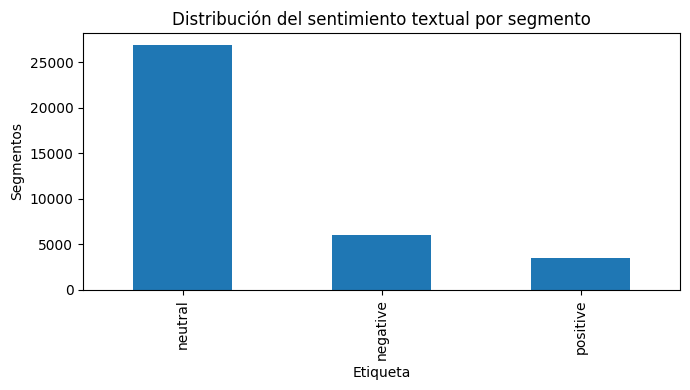

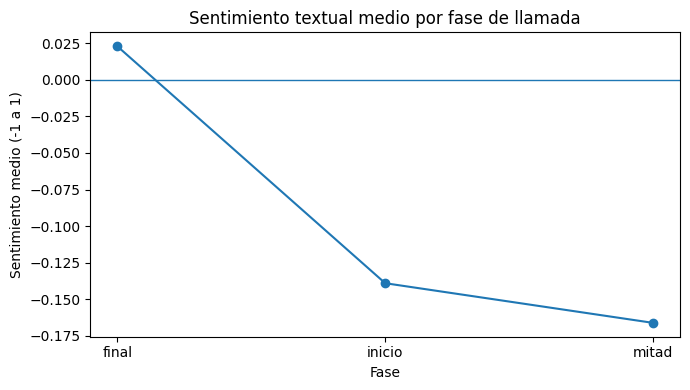

Llamadas con sentimiento cliente más negativo:


,audio_file,audio_stem,role_proxy,n_segments,total_words,total_duration,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive,role_sentiment_label
65,raw_9154635155880006851_clean.wav,raw_9154635155880006851_clean,CLIENT,2,36,10.293750,-1.000000,0.871507,1.000000,0.000000,0.00000,negative
943,raw_bajas_9156520333980006851_clean.wav,raw_bajas_9156520333980006851_clean,CLIENT,2,21,4.404375,-1.000000,0.865851,1.000000,0.000000,0.00000,negative
1223,raw_bajas_9156786673410006851_clean.wav,raw_bajas_9156786673410006851_clean,CLIENT,12,176,47.570625,-0.833333,0.774935,0.833333,0.166667,0.00000,negative
2323,raw_bajas_9157452496450006851_clean.wav,raw_bajas_9157452496450006851_clean,CLIENT,6,335,86.906250,-0.833333,0.847570,0.833333,0.166667,0.00000,negative
17,raw_9154281641250016851_clean.wav,raw_9154281641250016851_clean,CLIENT,4,167,53.038125,-0.750000,0.722952,0.750000,0.250000,0.00000,negative
1175,raw_bajas_9156725216470006851_clean.wav,raw_bajas_9156725216470006851_clean,CLIENT,8,118,36.736875,-0.750000,0.769789,0.750000,0.250000,0.00000,negative
2159,raw_bajas_9157365394740006851_clean.wav,raw_bajas_9157365394740006851_clean,CLIENT,4,53,14.866875,-0.750000,0.751091,0.750000,0.250000,0.00000,negative
1789,raw_bajas_9157236405500006851_clean.wav,raw_bajas_9157236405500006851_clean,CLIENT,32,531,148.651875,-0.718750,0.815427,0.750000,0.218750,0.03125,negative
539,raw_bajas_9156182796590006851_clean.wav,raw_bajas_9156182796590006851_clean,CLIENT,7,49,14.596875,-0.714286,0.736996,0.714286,0.285714,0.00000,negative
587,raw_bajas_9156252092130006851_clean.wav,raw_bajas_9156252092130006851_clean,CLIENT,7,211,72.967500,-0.714286,0.722420,0.714286,0.285714,0.00000,negative


In [10]:
# Figura original: distribución segmental.
fig, ax = plt.subplots(figsize=(7, 4))
sentiment_distribution.set_index("sentiment_label")["n_segments"].plot(
    kind="bar", ax=ax
)
ax.set_title("Distribución del sentimiento textual por segmento")
ax.set_xlabel("Etiqueta")
ax.set_ylabel("Segmentos")
plt.tight_layout()
plt.savefig(
    SENTIMENT_FIGURES_DIR / "sentiment_distribution_segments.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# Figura original: evolución global por fase de llamada.
global_temporal = sentiment_aggregates.get("global_temporal", pd.DataFrame())
if global_temporal.empty and not sentiment_aggregates["temporal_sentiment"].empty:
    global_temporal = (
        sentiment_aggregates["temporal_sentiment"]
        .groupby("call_phase", observed=False, dropna=False)
        .agg(avg_sentiment=("avg_sentiment", "mean"), n_segments=("n_segments", "sum"))
        .reset_index()
    )

if not global_temporal.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        global_temporal["call_phase"].astype(str),
        global_temporal["avg_sentiment"],
        marker="o",
    )
    ax.axhline(0, linewidth=1)
    ax.set_title("Sentimiento textual medio por fase de llamada")
    ax.set_xlabel("Fase")
    ax.set_ylabel("Sentimiento medio (-1 a 1)")
    plt.tight_layout()
    plt.savefig(
        SENTIMENT_FIGURES_DIR / "sentiment_temporal_global.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

client_negative_calls = sentiment_aggregates["call_role_sentiment"]
client_negative_calls = client_negative_calls[
    client_negative_calls["role_proxy"] == "CLIENT"
].sort_values(["avg_sentiment", "pct_negative"], ascending=[True, False]).head(10)
print("Llamadas con sentimiento cliente más negativo:")
display(client_negative_calls)

## 07A.6 — Sincronización exclusiva de sentimiento textual

In [11]:
upload_07a = upload_directory(
    local_dir=SENTIMENT_DIR,
    gcs_prefix=GCS_SENTIMENT_PREFIX,
    gcs_client=gcs_client,
    skip_unchanged=True,
)
print("Sincronización 07A:", upload_07a)

Subiendo outputs 1/11: all_segments_sentiment_textual_enriched.csv
Subiendo outputs 2/11: call_level_sentiment_textual.csv
Subiendo outputs 3/11: call_role_level_sentiment_textual.csv
Subiendo outputs 4/11: figures/sentiment_distribution_segments.png
Subiendo outputs 5/11: figures/sentiment_temporal_global.png
Subiendo outputs 6/11: role_level_sentiment_textual.csv
Subiendo outputs 7/11: segments_with_sentiment_textual.csv
Subiendo outputs 8/11: sentiment_segments_checkpoint.csv
Subiendo outputs 9/11: sentiment_textual_summary_for_memory.csv
Subiendo outputs 10/11: speaker_level_sentiment_textual.csv
Subiendo outputs 11/11: temporal_sentiment_textual.csv
Subida final completada.
Archivos locales revisados: 11
Archivos subidos: 11
Archivos omitidos sin cambios: 0
Destino: gs://catedras_audio_detection/pipelineA/procesados_UNAV/sentiment_outputs/
Sincronización 07A: {'total': 11, 'uploaded': 11, 'skipped': 0}


# 07B — Análisis afectivo del audio y prosodia

Esta fase trabaja directamente con los segmentos de audio. Conserva dos señales independientes:

- clasificación emocional mediante `UMUTeam/w2v-bert-emotion-es`;
- proxies prosódicos calculados con las fórmulas y umbrales originales.

Cada componente puede reutilizarse por separado y ningún modelo se carga si su output final ya existe.

## 07B.1 — Restauración y estado de outputs

In [12]:
restore_07b = download_directory(
    local_dir=PROSODY_DIR,
    gcs_prefix=GCS_UNAV_ROOT,
    gcs_client=gcs_client,
    base_dir=DATA_DIR,
)

prosody_core_outputs = [
    SEGMENTS_PROSODY_CSV,
    CALL_PROSODY_CSV,
    CALL_ROLE_PROSODY_CSV,
    CALL_SPEAKER_PROSODY_CSV,
    ROLE_PROSODY_CSV,
    PROSODY_SUMMARY_CSV,
]
prosody_outputs_ready = (
    aa.outputs_complete(prosody_core_outputs)
    and not FORCE_RECALCULATE_PROSODY
)
ser_output_ready = (
    SER_PREDICTIONS_CSV.exists()
    and SER_PREDICTIONS_CSV.stat().st_size > 0
    and not FORCE_RECALCULATE_SER
)

status_07b = pd.DataFrame(
    {
        "output": [path.name for path in prosody_paths.values()],
        "exists": [path.exists() for path in prosody_paths.values()],
        "size_bytes": [path.stat().st_size if path.exists() else 0 for path in prosody_paths.values()],
    }
)
display(status_07b)
print("Prosodia final reutilizable:", prosody_outputs_ready)
print("SER final reutilizable:", ser_output_ready)

Restauración desde GCS completada.
Archivos encontrados: 0
Archivos descargados: 0
Archivos locales ya vigentes: 0


,output,exists,size_bytes
0,segments_with_audio_affect_prosody.csv,True,61661016
1,call_level_audio_affect_prosody.csv,True,706347
2,call_role_level_audio_affect_prosody.csv,True,1433108
3,call_speaker_level_audio_affect_prosody.csv,True,1443599
4,role_level_audio_affect_prosody.csv,True,1652
5,prosody_audio_affect_summary_for_memory.csv,True,739
6,ser_model_predictions.csv,True,11169303
7,audio_vs_textual_sentiment_comparison.csv,True,65653857


Prosodia final reutilizable: True
SER final reutilizable: True


In [13]:
# Restaurar segmentos y WAV solo si se necesita recalcular audio.
needs_audio_inputs = not prosody_outputs_ready or not ser_output_ready
if needs_audio_inputs:
    restore_proxy_07b = download_directory(
        local_dir=PROXY_GROUNDTRUTH_DIR,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )
    restore_relabel_07b = download_directory(
        local_dir=FINAL_RELABEL_DIR,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )
    restore_audio_07b = download_prefix_to_local(
        source_uri=GCS_CLEAN_AUDIO_PREFIX,
        local_dir=INPUT_DIR,
        gcs_client=gcs_client,
        suffix=".wav",
        force=FORCE_RESTORE_INPUTS,
    )
    print("Inputs de audio 07B restaurados.")
else:
    print("No se descargan WAV: SER y prosodia ya tienen outputs finales.")

# El sentimiento textual es un input liviano necesario para validar/reconstruir el cruce 07B.
restore_text_07b = download_directory(
    local_dir=SENTIMENT_DIR,
    gcs_prefix=GCS_UNAV_ROOT,
    gcs_client=gcs_client,
    base_dir=DATA_DIR,
)

No se descargan WAV: SER y prosodia ya tienen outputs finales.
Restauración desde GCS completada.
Archivos encontrados: 11
Archivos descargados: 0
Archivos locales ya vigentes: 11


## 07B.2 — Preparación y filtros de segmentos

In [14]:
if prosody_outputs_ready and ser_output_ready:
    loaded_07b = aa.load_prosody_outputs(prosody_paths)
    df_scores = aa.add_demo_compatibility_columns(loaded_07b["segments"])
    df_ser_predictions = loaded_07b.get("ser", pd.DataFrame())
    prosody_aggregates = {
        "call": loaded_07b["call"],
        "call_role": loaded_07b["call_role"],
        "call_speaker": loaded_07b["call_speaker"],
        "role": loaded_07b["role"],
    }
    prosody_summary = loaded_07b["summary"]
    df_audio_text_comparison = loaded_07b.get("comparison", pd.DataFrame())
    prosody_source = "outputs_07B_reutilizados"
    print("07B reutilizada sin cargar audio ni modelos.")
else:
    df_segments, prosody_columns, prosody_input_path = aa.load_and_prepare_segments(
        proxy_segment_csv=PROXY_SEGMENT_LEVEL_CSV,
        fallback_segments_csv=ALL_FINAL_MERGED_SEGMENTS_CSV,
    )
    df_prosody_candidates = aa.filter_prosody_candidates(
        df_segments=df_segments,
        columns=prosody_columns,
        min_segment_duration_sec=MIN_SEGMENT_DURATION_SEC,
        max_segment_duration_sec=MAX_SEGMENT_DURATION_SEC,
        max_overlap_ratio_prosody=MAX_OVERLAP_RATIO_PROSODY,
        min_rms_dbfs_input=MIN_RMS_DBFS_INPUT,
        require_role_proxy=REQUIRE_ROLE_PROXY,
        max_segments_debug=MAX_SEGMENTS_DEBUG,
    )
    audio_index = aa.build_audio_index([INPUT_DIR])
    prosody_source = f"recalculado_desde_{prosody_input_path.name}"

    print("Segmentos de entrada:", len(df_segments))
    print("Segmentos candidatos:", len(df_prosody_candidates))
    print("Audios candidatos:", df_prosody_candidates["audio_stem_norm"].nunique())
    print("WAV indexados:", len({str(path) for path in audio_index.values()}))
    display(df_prosody_candidates["role_proxy_for_prosody"].value_counts(dropna=False).to_frame("n_segments"))
    display(df_prosody_candidates.head(10))

print("Fuente 07B:", prosody_source)

07B reutilizada sin cargar audio ni modelos.
Fuente 07B: outputs_07B_reutilizados


## 07B.3 — Modelo emocional del audio (SER)

In [15]:
if ser_output_ready:
    df_ser_predictions = pd.read_csv(SER_PREDICTIONS_CSV)
    print("SER reutilizado; el modelo no se carga.")
elif RUN_PRETRAINED_SER_MODEL:
    ser_pipeline, ser_device = aa.load_ser_pipeline(
        model_id=SER_MODEL_ID,
        hf_token=HF_TOKEN,
    )
    print("Modelo SER cargado en:", ser_device)
    df_ser_predictions = aa.apply_ser_with_checkpoint(
        df_candidates=df_prosody_candidates,
        columns=prosody_columns,
        audio_index=audio_index,
        ser_pipeline=ser_pipeline,
        model_id=SER_MODEL_ID,
        checkpoint_csv=SER_CHECKPOINT_CSV,
        predictions_csv=SER_PREDICTIONS_CSV,
        target_sr=TARGET_SAMPLE_RATE,
        save_every=SER_SAVE_EVERY,
        resume_from_checkpoint=True,
        force=FORCE_RECALCULATE_SER,
        max_segments=MAX_SEGMENTS_DEBUG,
    )
else:
    df_ser_predictions = pd.DataFrame()
    print("RUN_PRETRAINED_SER_MODEL=False: SER omitido.")

print("Predicciones SER disponibles:", len(df_ser_predictions))
if not df_ser_predictions.empty:
    display(df_ser_predictions.head(10))

SER reutilizado; el modelo no se carga.
Predicciones SER disponibles: 35910


,prosody_row_id,audio_stem_norm,audio_file_norm,start,end,speaker_for_prosody,role_proxy_for_prosody,ser_model_id,ser_pred_label,ser_pred_score,ser_prob_disgust,ser_prob_neutral,ser_prob_anger,ser_prob_sadness,ser_prob_fear,ser_prob_joy,interval
0,0,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,0.030969,4.452219,SPEAKER_01,AGENT,UMUTeam/w2v-bert-emotion-es,disgust,0.192178,0.192178,0.180379,0.163730,0.158886,0.152644,0.152182,NaN
1,1,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,5.211594,6.342219,SPEAKER_00,CLIENT,UMUTeam/w2v-bert-emotion-es,sadness,0.243924,0.138848,0.130818,0.192789,0.243924,0.146892,0.146729,NaN
2,2,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,6.426594,13.800969,SPEAKER_01,AGENT,UMUTeam/w2v-bert-emotion-es,disgust,0.192519,0.192519,0.181522,0.163743,0.155080,0.153258,0.153878,NaN
3,3,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,13.800969,14.965344,SPEAKER_00,CLIENT,UMUTeam/w2v-bert-emotion-es,neutral,0.188290,0.161137,0.188290,0.159235,0.153809,0.162026,0.175503,NaN
4,4,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,15.285969,19.994094,SPEAKER_01,AGENT,UMUTeam/w2v-bert-emotion-es,disgust,0.184102,0.184102,0.179221,0.163592,0.155137,0.153361,0.164587,NaN
5,5,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,22.727844,23.790969,SPEAKER_01,AGENT,UMUTeam/w2v-bert-emotion-es,disgust,0.203815,0.203815,0.156263,0.133799,0.157204,0.190945,0.157974,NaN
6,6,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,25.225344,25.967844,SPEAKER_01,AGENT,UMUTeam/w2v-bert-emotion-es,neutral,0.188883,0.169779,0.188883,0.155737,0.145118,0.163531,0.176951,NaN
7,7,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,31.300344,33.443469,SPEAKER_01,AGENT,UMUTeam/w2v-bert-emotion-es,sadness,0.227816,0.149708,0.144230,0.182940,0.227816,0.146923,0.148383,NaN
8,8,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,34.337844,37.189719,SPEAKER_01,AGENT,UMUTeam/w2v-bert-emotion-es,neutral,0.189086,0.157705,0.189086,0.162717,0.153243,0.160309,0.176941,NaN
9,9,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,37.189719,39.839094,SPEAKER_00,CLIENT,UMUTeam/w2v-bert-emotion-es,fear,0.194384,0.192302,0.184283,0.120633,0.136924,0.194384,0.171474,NaN


## 07B.4 — Extracción prosódica y cálculo de scores

In [16]:
if prosody_outputs_ready:
    if "df_scores" not in globals():
        df_scores = aa.add_demo_compatibility_columns(pd.read_csv(SEGMENTS_PROSODY_CSV))
    print("Features y scores prosódicos reutilizados.")
else:
    df_prosody_features, prosody_diagnostics = aa.extract_prosodic_features_with_checkpoint(
        df_candidates=df_prosody_candidates,
        columns=prosody_columns,
        audio_index=audio_index,
        checkpoint_csv=PROSODY_FEATURES_CHECKPOINT_CSV,
        target_sr=TARGET_SAMPLE_RATE,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH,
        fmin=FMIN,
        fmax=FMAX,
        save_every_audios=PROSODY_SAVE_EVERY_AUDIOS,
        resume_from_checkpoint=True,
        force=FORCE_RECALCULATE_PROSODY,
    )
    print("Diagnóstico de extracción:", prosody_diagnostics)
    display(df_prosody_features["prosody_status"].value_counts(dropna=False).to_frame("n_segments"))

    df_scores = aa.compute_prosodic_scores(df_prosody_features)

# La integración es barata y se repite para asegurar que outputs restaurados y nuevos
# compartan las mismas predicciones y aliases que consume la demo.
df_scores = aa.merge_ser_predictions(
    df_scores=df_scores,
    df_ser_predictions=df_ser_predictions,
    merge_into_existing=True,
)
df_scores = aa.add_demo_compatibility_columns(df_scores)

print("Segmentos con output afectivo:", len(df_scores))
if "prosody_status" in df_scores.columns:
    display(df_scores["prosody_status"].value_counts(dropna=False).to_frame("n_segments"))
display(
    df_scores[
        [column for column in [
            "audio_file_norm", "interval", "role_proxy_for_prosody",
            "ser_pred_label", "ser_pred_score", "prosodic_state_proxy",
            "arousal_proxy_score", "tension_proxy_score"
        ] if column in df_scores.columns]
    ].head(10)
)

Features y scores prosódicos reutilizados.
Segmentos con output afectivo: 35910


,n_segments
prosody_status,
ok,35910


,audio_file_norm,interval,role_proxy_for_prosody,ser_pred_label,ser_pred_score,prosodic_state_proxy,arousal_proxy_score,tension_proxy_score
0,raw_9154117451310006851_clean.wav,00:00.03 - 00:04.45,AGENT,disgust,0.192178,neutral_prosodico,0.521993,0.610595
1,raw_9154117451310006851_clean.wav,00:05.21 - 00:06.34,CLIENT,sadness,0.243924,neutral_prosodico,0.441332,0.275878
2,raw_9154117451310006851_clean.wav,00:06.43 - 00:13.80,AGENT,disgust,0.192519,neutral_prosodico,0.455894,0.457755
3,raw_9154117451310006851_clean.wav,00:13.80 - 00:14.97,CLIENT,neutral,0.188290,neutral_prosodico,0.549870,0.452922
4,raw_9154117451310006851_clean.wav,00:15.29 - 00:19.99,AGENT,disgust,0.184102,alta_tension_prosodica,0.617328,0.798132
5,raw_9154117451310006851_clean.wav,00:22.73 - 00:23.79,AGENT,disgust,0.203815,alta_tension_prosodica,0.994615,1.000000
6,raw_9154117451310006851_clean.wav,00:25.23 - 00:25.97,AGENT,neutral,0.188883,neutral_prosodico,0.406635,0.345311
7,raw_9154117451310006851_clean.wav,00:31.30 - 00:33.44,AGENT,sadness,0.227816,calma_prosodica,0.152493,0.265761
8,raw_9154117451310006851_clean.wav,00:34.34 - 00:37.19,AGENT,neutral,0.189086,neutral_prosodico,0.625640,0.736078
9,raw_9154117451310006851_clean.wav,00:37.19 - 00:39.84,CLIENT,fear,0.194384,alta_tension_prosodica,0.748018,0.825949


## 07B.5 — Agregados y cruce con sentimiento textual

In [17]:
df_text_sentiment = (
    pd.read_csv(SEGMENTS_WITH_SENTIMENT_CSV)
    if SEGMENTS_WITH_SENTIMENT_CSV.exists() and SEGMENTS_WITH_SENTIMENT_CSV.stat().st_size > 0
    else pd.DataFrame()
)

start_col_audio = aa.detect_col(
    df_scores, ["start", "start_sec", "start_time"], required=True, label="start audio"
)
end_col_audio = aa.detect_col(
    df_scores, ["end", "end_sec", "end_time"], required=True, label="end audio"
)

df_audio_text_comparison, comparison_diagnostics = aa.build_audio_text_comparison(
    df_scores=df_scores,
    df_text_sentiment=df_text_sentiment,
    start_col=start_col_audio,
    end_col=end_col_audio,
)
print("Diagnóstico del cruce audio-texto:", comparison_diagnostics)

# Siempre se recalculan estos agregados ligeros para que reflejen el output segmental vigente.
prosody_aggregates = aa.build_prosody_aggregates(df_scores)
if prosody_outputs_ready and "prosody_summary" in globals():
    pass
else:
    prosody_summary = aa.build_prosody_summary(
        df_segments=df_segments,
        df_candidates=df_prosody_candidates,
        df_scores=df_scores,
        df_ser_predictions=df_ser_predictions,
        model_id=SER_MODEL_ID,
        run_pretrained_ser_model=RUN_PRETRAINED_SER_MODEL,
    )

saved_07b = aa.save_prosody_outputs(
    df_scores=df_scores,
    aggregates=prosody_aggregates,
    summary=prosody_summary,
    paths=prosody_paths,
    comparison=df_audio_text_comparison,
)

print("Outputs 07B guardados/actualizados:", len(saved_07b))
display(prosody_aggregates["role"].round(4))
display(prosody_summary)
if not df_audio_text_comparison.empty:
    comparison_preview_columns = [column for column in [
        "audio_stem_norm", "interval", "role_proxy_for_prosody", "text_whisper",
        "sentiment_label", "sentiment_numeric", "ser_pred_label",
        "prosodic_state_proxy", "tension_proxy_score"
    ] if column in df_audio_text_comparison.columns]
    display(df_audio_text_comparison[comparison_preview_columns].head(10))

Diagnóstico del cruce audio-texto: {'matched_text': 32414, 'rows': 35910, 'unique_audio': 1166}
Outputs 07B guardados/actualizados: 7


,role_proxy_for_prosody,n_segments_prosody,total_seconds_prosody,duration_for_prosody_mean,arousal_proxy_score_mean,arousal_proxy_score_median,arousal_proxy_score_max,tension_proxy_score_mean,tension_proxy_score_median,tension_proxy_score_max,...,pitch_std_median,voiced_ratio_mean,ser_pred_score_mean,ser_pred_score_median,ser_prob_disgust_mean,ser_prob_neutral_mean,ser_prob_anger_mean,ser_prob_sadness_mean,ser_prob_fear_mean,ser_prob_joy_mean
0,AGENT,18999,88980.6769,4.6834,0.4142,0.4197,1.0,0.3505,0.3367,1.0,...,29.2252,0.7578,0.2004,0.2001,0.1780,0.1631,0.1786,0.1617,0.1627,0.1560
1,CLIENT,16911,61553.5031,3.6398,0.4958,0.4954,1.0,0.3406,0.3123,1.0,...,24.1878,0.7401,0.1958,0.1925,0.1778,0.1659,0.1646,0.1690,0.1686,0.1541


,n_segments_input,n_segments_candidates,n_segments_audio_affect_output,n_segments_prosody_ok,n_audios_audio_affect,n_roles,ser_model_used,ser_model_id,n_ser_predictions,mean_arousal_proxy_score,...,mean_tension_proxy_score,median_tension_proxy_score,mean_intensity_proxy_score,median_intensity_proxy_score,mean_calm_proxy_score,median_calm_proxy_score,mean_ser_pred_score,median_ser_pred_score,most_common_ser_label,most_common_ser_label_n
0,40352,35910,35910,35910,1166,2,True,UMUTeam/w2v-bert-emotion-es,35910,0.452538,...,0.345828,0.326103,0.448184,0.432176,0.547462,0.557237,0.198236,0.196468,anger,12262


,audio_stem_norm,interval,role_proxy_for_prosody,text_whisper,sentiment_label,sentiment_numeric,ser_pred_label,prosodic_state_proxy,tension_proxy_score
0,raw_9154117451310006851_clean,00:00.03 - 00:04.45,AGENT,"Hola, buenos días. Pregunto por Luis Ángel. So...",neutral,0.0,disgust,neutral_prosodico,0.610595
1,raw_9154117451310006851_clean,00:05.21 - 00:06.34,CLIENT,"Sí, cuéntame.",neutral,0.0,sadness,neutral_prosodico,0.275878
2,raw_9154117451310006851_clean,00:06.43 - 00:13.80,AGENT,"Hola Luis, me encanta saludarte. El motivo de ...",positive,1.0,disgust,neutral_prosodico,0.457755
3,raw_9154117451310006851_clean,00:13.80 - 00:14.97,CLIENT,NaN,NaN,NaN,neutral,neutral_prosodico,0.452922
4,raw_9154117451310006851_clean,00:15.29 - 00:19.99,AGENT,han llamado los técnicos de plantas terna o al...,neutral,0.0,disgust,alta_tension_prosodica,0.798132
5,raw_9154117451310006851_clean,00:22.73 - 00:23.79,AGENT,¿Ahora tienes internet?,neutral,0.0,disgust,alta_tension_prosodica,1.000000
6,raw_9154117451310006851_clean,00:25.23 - 00:25.97,AGENT,"Vale, pues",neutral,0.0,neutral,neutral_prosodico,0.345311
7,raw_9154117451310006851_clean,00:31.30 - 00:33.44,AGENT,Pues es que no nos habían dicho nada.,negative,-1.0,sadness,calma_prosodica,0.265761
8,raw_9154117451310006851_clean,00:34.34 - 00:37.19,AGENT,"Es el tamilloso, ¿no? Donde tenías la incidencia.",neutral,0.0,neutral,neutral_prosodico,0.736078
9,raw_9154117451310006851_clean,00:37.19 - 00:39.84,CLIENT,"Ay, vamos, yo estoy trabajando y bien.",positive,1.0,fear,alta_tension_prosodica,0.825949


## 07B.6 — Visualizaciones del afecto acústico

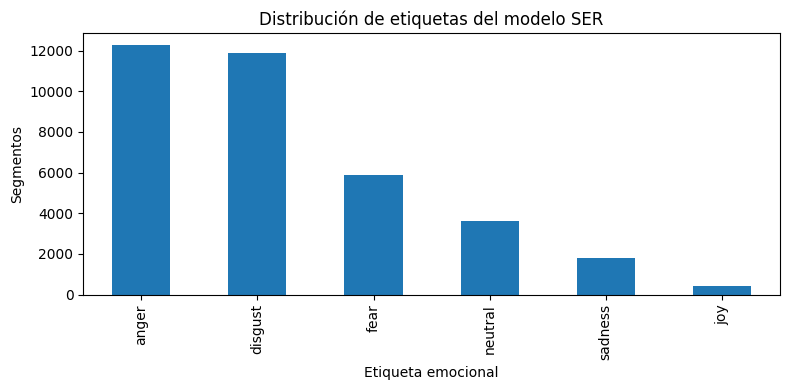

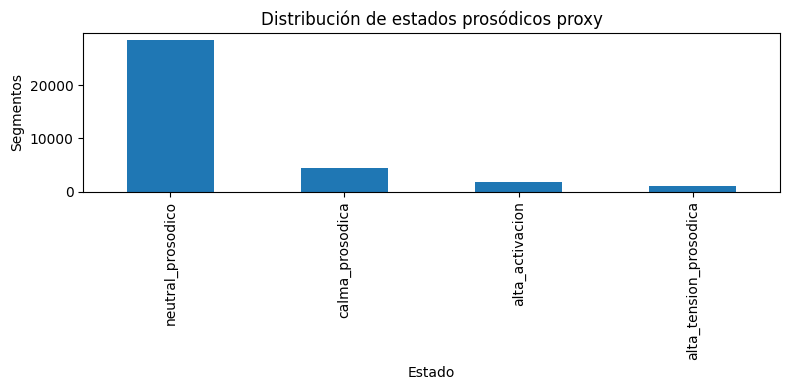

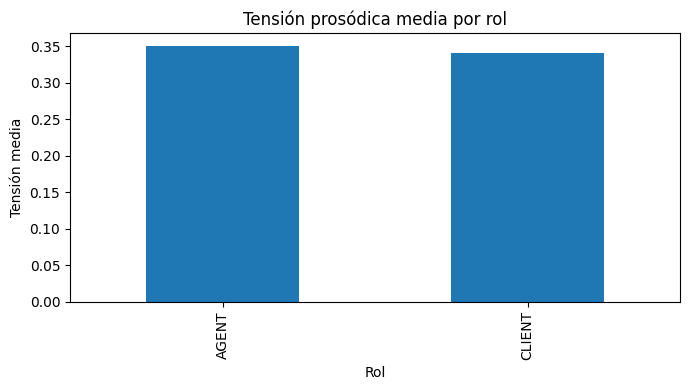

In [18]:
if "ser_pred_label" in df_scores.columns and df_scores["ser_pred_label"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    df_scores["ser_pred_label"].value_counts().plot(kind="bar", ax=ax)
    ax.set_title("Distribución de etiquetas del modelo SER")
    ax.set_xlabel("Etiqueta emocional")
    ax.set_ylabel("Segmentos")
    plt.tight_layout()
    plt.show()

if "prosodic_state_proxy" in df_scores.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    df_scores["prosodic_state_proxy"].value_counts().plot(kind="bar", ax=ax)
    ax.set_title("Distribución de estados prosódicos proxy")
    ax.set_xlabel("Estado")
    ax.set_ylabel("Segmentos")
    plt.tight_layout()
    plt.show()

if {"role_proxy_for_prosody", "tension_proxy_score"}.issubset(df_scores.columns):
    tension_by_role = (
        df_scores.groupby("role_proxy_for_prosody", dropna=False)["tension_proxy_score"]
        .mean()
        .sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    tension_by_role.plot(kind="bar", ax=ax)
    ax.set_title("Tensión prosódica media por rol")
    ax.set_xlabel("Rol")
    ax.set_ylabel("Tensión media")
    plt.tight_layout()
    plt.show()

## 07B.7 — Sincronización exclusiva de afecto acústico

In [19]:
upload_07b = upload_directory(
    local_dir=PROSODY_DIR,
    gcs_prefix=GCS_PROSODY_PREFIX,
    gcs_client=gcs_client,
    skip_unchanged=True,
)
print("Sincronización 07B:", upload_07b)

Subiendo outputs 1/13: audio_vs_textual_sentiment_comparison.csv
Subiendo outputs 2/13: call_level_audio_affect_prosody.csv
Subiendo outputs 3/13: call_role_level_audio_affect_prosody.csv
Subiendo outputs 4/13: call_speaker_level_audio_affect_prosody.csv
Subiendo outputs 5/13: figures/quick_role_level_prosody_scores.png
Subiendo outputs 6/13: figures/quick_tension_proxy_distribution.png
Subiendo outputs 7/13: prosody_audio_affect_summary_for_memory.csv
Subiendo outputs 8/13: prosody_features_checkpoint.csv
Subiendo outputs 9/13: role_level_audio_affect_prosody.csv
Subiendo outputs 10/13: segments_with_audio_affect_prosody.csv
Subiendo outputs 11/13: ser_model_predictions.csv
Subiendo outputs 12/13: ser_model_predictions_checkpoint.csv
Subiendo outputs 13/13: ser_model_predictions_optional.csv
Subida final completada.
Archivos locales revisados: 13
Archivos subidos: 13
Archivos omitidos sin cambios: 0
Destino: gs://catedras_audio_detection/pipelineA/procesados_UNAV/prosody_outputs/
Sinc

# 07C — Fusión audio–texto

La fase valida primero el CSV de comparación generado por 07B. Si fue creado con un esquema antiguo, contiene texto vacío o no produce segmentos comparables, la unión se reconstruye desde los outputs finales de 07A y 07B usando audio y timestamps. Esta validación evita que la matriz audio–texto quede vacía por incompatibilidad de etiquetas o columnas.

## 07C.1 — Restauración y validación del output fusionado

In [20]:
restore_07c = download_directory(
    local_dir=SENTIMENT_FUSION_DIR,
    gcs_prefix=GCS_UNAV_ROOT,
    gcs_client=gcs_client,
    base_dir=DATA_DIR,
)

fusion_reusable = (
    fat.fusion_output_is_compatible(FUSION_SEGMENTS_CSV)
    and not FORCE_RECALCULATE_07C
)

if fusion_reusable:
    df_fusion = fat.normalize_fusion_schema(pd.read_csv(FUSION_SEGMENTS_CSV))
    fusion_source = "output_07C_compatible_reutilizado"
    print("Fusión existente compatible; no se reconstruye la unión.")
else:
    restore_text_07c = download_directory(
        local_dir=SENTIMENT_DIR,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )
    restore_audio_07c = download_directory(
        local_dir=PROSODY_DIR,
        gcs_prefix=GCS_UNAV_ROOT,
        gcs_client=gcs_client,
        base_dir=DATA_DIR,
    )

    df_audio_07c = pd.read_csv(SEGMENTS_PROSODY_CSV)
    df_text_07c = pd.read_csv(SEGMENTS_WITH_SENTIMENT_CSV)
    df_comparison_07b = (
        pd.read_csv(AUDIO_TEXT_COMPARISON_CSV)
        if AUDIO_TEXT_COMPARISON_CSV.exists() and AUDIO_TEXT_COMPARISON_CSV.stat().st_size > 0
        else pd.DataFrame()
    )
    df_fusion, fusion_source = fat.build_fusion_dataframe(
        df_audio=df_audio_07c,
        df_text=df_text_07c,
        df_existing_comparison=df_comparison_07b,
    )

print("Fuente de la fusión:", fusion_source)
print("Filas fusionadas:", len(df_fusion))
display(
    df_fusion[
        [column for column in [
            "audio_stem_norm", "start", "end", "role", "text_whisper",
            "sentiment_label_norm", "sentiment_numeric", "ser_pred_label",
            "prosodic_state_proxy", "tension_proxy_score", "has_audio", "has_text"
        ] if column in df_fusion.columns]
    ].head(10)
)

Restauración desde GCS completada.
Archivos encontrados: 0
Archivos descargados: 0
Archivos locales ya vigentes: 0
Fusión existente compatible; no se reconstruye la unión.
Fuente de la fusión: output_07C_compatible_reutilizado
Filas fusionadas: 32193


,audio_stem_norm,start,end,role,sentiment_label_norm,sentiment_numeric,ser_pred_label,prosodic_state_proxy,tension_proxy_score,has_audio,has_text
0,raw_9154117451310006851_clean,0.030969,4.452219,agent,neutral,0.0,disgust,neutral_prosodico,0.610595,True,True
1,raw_9154117451310006851_clean,5.211594,6.342219,client,neutral,0.0,sadness,neutral_prosodico,0.275878,True,True
2,raw_9154117451310006851_clean,6.426594,13.800969,agent,positivo,1.0,disgust,neutral_prosodico,0.457755,True,True
3,raw_9154117451310006851_clean,15.285969,19.994094,agent,neutral,0.0,disgust,alta_tension_prosodica,0.798132,True,True
4,raw_9154117451310006851_clean,22.727844,23.790969,agent,neutral,0.0,disgust,alta_tension_prosodica,1.000000,True,True
5,raw_9154117451310006851_clean,25.225344,25.967844,agent,neutral,0.0,neutral,neutral_prosodico,0.345311,True,True
6,raw_9154117451310006851_clean,31.300344,33.443469,agent,negativo,-1.0,sadness,calma_prosodica,0.265761,True,True
7,raw_9154117451310006851_clean,34.337844,37.189719,agent,neutral,0.0,neutral,neutral_prosodico,0.736078,True,True
8,raw_9154117451310006851_clean,37.189719,39.839094,client,positivo,1.0,fear,alta_tension_prosodica,0.825949,True,True
9,raw_9154117451310006851_clean,40.800969,48.242844,client,negativo,-1.0,disgust,neutral_prosodico,0.591401,True,True


## 07C.2 — Cobertura multimodal

,segments_total,both,only_audio,only_text,pct_comparable
0,32193,32193,0,0,100.0


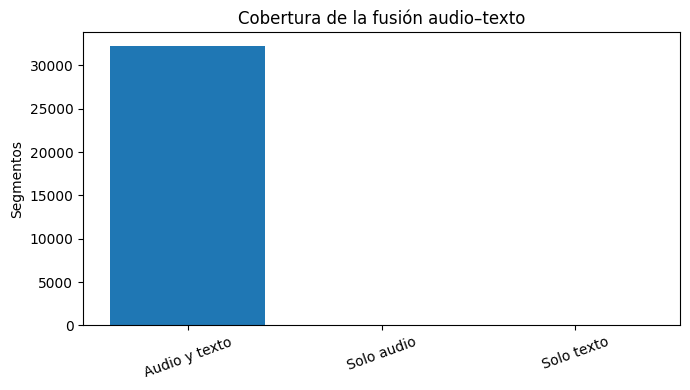

In [21]:
coverage_07c = fat.compute_coverage(df_fusion)
coverage_table = pd.DataFrame(
    [
        {"grupo": "Audio y texto", "segmentos": coverage_07c["both"]},
        {"grupo": "Solo audio", "segmentos": coverage_07c["only_audio"]},
        {"grupo": "Solo texto", "segmentos": coverage_07c["only_text"]},
    ]
)
display(pd.DataFrame([coverage_07c]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(coverage_table["grupo"], coverage_table["segmentos"])
ax.set_title("Cobertura de la fusión audio–texto")
ax.set_ylabel("Segmentos")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(SENTIMENT_FUSION_FIGURES_DIR / "fase1_cobertura.png", dpi=120, bbox_inches="tight")
plt.show()

## 07C.3 — Concordancia y matriz de confusión

Segmentos comparables: 32193


,score_audio,n,pearson_r,pearson_p,spearman_r,spearman_p
0,arousal_proxy_score,32193,-0.093,0.0000,-0.090,0.0000
1,tension_proxy_score,32193,-0.041,0.0000,-0.041,0.0000
2,intensity_proxy_score,32193,-0.105,0.0000,-0.102,0.0000
3,ser_neg_prob,32193,0.005,0.4084,0.005,0.4125


sentiment_label_norm,negativo,neutral,positivo
prosodic_state_proxy,,,
alta_activacion,410,1065,93
alta_tension_prosodica,160,686,75
calma_prosodica,554,2741,514
neutral_prosodico,4303,19474,2118


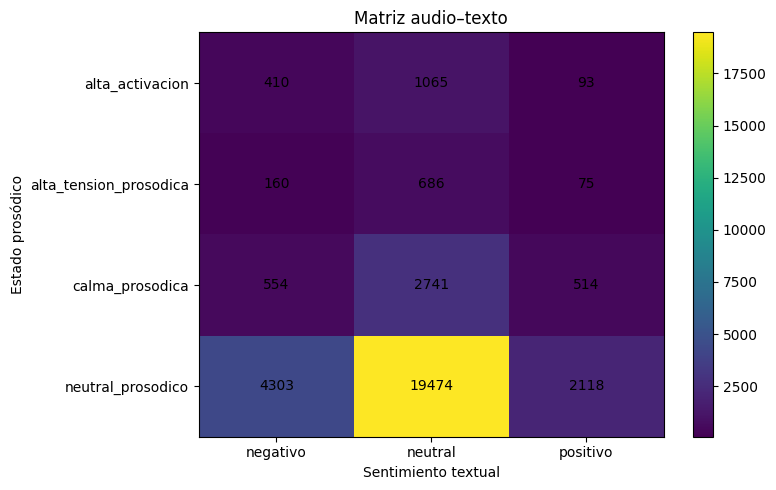

In [22]:
df_comparable = fat.comparable_segments(df_fusion)
df_correlations = fat.compute_correlations(df_comparable)
df_confusion = fat.compute_confusion_matrix(df_comparable)

print("Segmentos comparables:", len(df_comparable))
display(df_correlations)
display(df_confusion)

if len(df_comparable) > 0 and df_confusion.empty:
    raise ValueError(
        "Hay segmentos comparables, pero la matriz quedó vacía. "
        "Revisar sentiment_label_norm y prosodic_state_proxy antes de continuar."
    )

if not df_confusion.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    image = ax.imshow(df_confusion.values, aspect="auto")
    ax.set_xticks(range(len(df_confusion.columns)))
    ax.set_xticklabels(df_confusion.columns)
    ax.set_yticks(range(len(df_confusion.index)))
    ax.set_yticklabels(df_confusion.index)
    ax.set_xlabel("Sentimiento textual")
    ax.set_ylabel("Estado prosódico")
    ax.set_title("Matriz audio–texto")
    for row in range(df_confusion.shape[0]):
        for column in range(df_confusion.shape[1]):
            ax.text(column, row, int(df_confusion.iloc[row, column]), ha="center", va="center")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.savefig(SENTIMENT_FUSION_FIGURES_DIR / "fase2_concordancia.png", dpi=120, bbox_inches="tight")
    plt.show()

## 07C.4 — Discordancias entre lo dicho y cómo se dijo

Umbrales de señal acústica alta: {'tension_proxy_score': 0.4385636155660871, 'arousal_proxy_score': 0.5556872464444347, 'ser_neg_prob': 0.1986921578645706}


,tipo,segmentos
0,Frustración enmascarada,13745
1,Negatividad contenida,2610


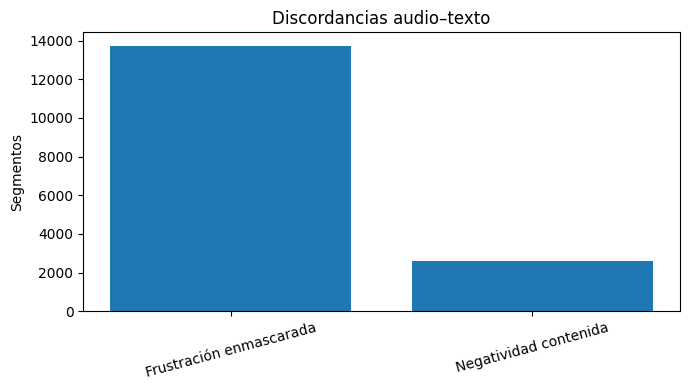

Ejemplos de frustración enmascarada:


,audio_stem_norm,start,end,role,sentiment_label_norm,sentiment_numeric,prosodic_state_proxy,ser_pred_label,arousal_proxy_score,tension_proxy_score
1694,raw_9155101148350016851_clean,117.734094,118.645344,client,neutral,0.0,alta_tension_prosodica,disgust,1.0,1.0
2331,raw_9155578970760016851_clean,48.310344,49.457844,client,neutral,0.0,alta_tension_prosodica,fear,1.0,1.0
3936,raw_9156027267320016851_clean,99.728469,100.791594,client,positivo,1.0,alta_tension_prosodica,fear,1.0,1.0
4249,raw_bajas_9156059374650006851_clean,72.306594,73.285344,client,neutral,0.0,alta_tension_prosodica,joy,1.0,1.0
4253,raw_bajas_9156059374650006851_clean,99.914094,104.520969,client,neutral,0.0,alta_tension_prosodica,anger,1.0,1.0
4275,raw_bajas_9156059374650006851_clean,195.004719,201.602844,client,neutral,0.0,alta_tension_prosodica,anger,1.0,1.0
4278,raw_bajas_9156059374650006851_clean,227.826594,229.041594,client,neutral,0.0,alta_tension_prosodica,fear,1.0,1.0
4707,raw_bajas_9156079148910016851_clean,101.415969,102.698469,client,positivo,1.0,alta_tension_prosodica,fear,1.0,1.0
4826,raw_bajas_9156094262250016851_clean,25.275969,27.334719,client,neutral,0.0,alta_tension_prosodica,disgust,1.0,1.0
4828,raw_bajas_9156094262250016851_clean,30.996594,31.975344,client,neutral,0.0,alta_tension_prosodica,disgust,1.0,1.0


In [23]:
df_disagreement, disagreement_thresholds = fat.compute_disagreement(
    df_comparable=df_comparable,
    audio_high_percentile=AUDIO_HIGH_PERCENTILE,
    text_nonnegative_threshold=TEXT_NONNEGATIVE_THRESHOLD,
)

print("Umbrales de señal acústica alta:", disagreement_thresholds)
if not df_disagreement.empty:
    disagreement_counts = pd.DataFrame(
        {
            "tipo": ["Frustración enmascarada", "Negatividad contenida"],
            "segmentos": [
                int(df_disagreement["masked_frustration"].sum()),
                int(df_disagreement["contained_negativity"].sum()),
            ],
        }
    )
    display(disagreement_counts)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(disagreement_counts["tipo"], disagreement_counts["segmentos"])
    ax.set_title("Discordancias audio–texto")
    ax.set_ylabel("Segmentos")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(SENTIMENT_FUSION_FIGURES_DIR / "fase3_discordancia.png", dpi=120, bbox_inches="tight")
    plt.show()

    masked_examples = df_disagreement[df_disagreement["masked_frustration"]].copy()
    masked_examples = masked_examples.sort_values(
        [column for column in ["tension_proxy_score", "arousal_proxy_score"] if column in masked_examples.columns],
        ascending=False,
    ).head(15)
    example_columns = [column for column in [
        "audio_stem_norm", "start", "end", "role", "text_whisper",
        "sentiment_label_norm", "sentiment_numeric", "prosodic_state_proxy",
        "ser_pred_label", "arousal_proxy_score", "tension_proxy_score"
    ] if column in masked_examples.columns]
    print("Ejemplos de frustración enmascarada:")
    display(masked_examples[example_columns])
else:
    print("No hay segmentos comparables para analizar discordancias.")

## 07C.5 — Perfil por rol, guardado y compatibilidad con la demo

,role,sentiment_numeric,arousal_proxy_score,tension_proxy_score,intensity_proxy_score,ser_neg_prob,masked_frustration,contained_negativity,n_segmentos
0,agent,-0.0423,0.4156,0.3505,0.3887,0.1793,0.4513,0.0661,17639
1,client,-0.1292,0.4982,0.3384,0.5247,0.1652,0.3975,0.0992,14554


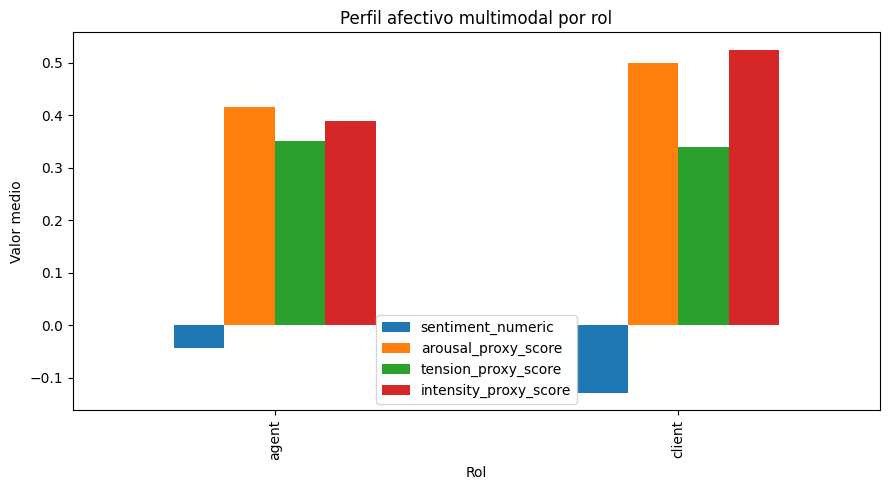

Outputs 07C guardados: 7


,metrica,valor
0,segmentos_totales,32193.000
1,segmentos_comparables,32193.000
2,pearson_arousal_proxy_score,-0.093
3,pearson_tension_proxy_score,-0.041
4,pearson_intensity_proxy_score,-0.105
5,pearson_ser_neg_prob,0.005
6,pct_frustracion_enmascarada,42.700


,column,present,non_null
0,sentiment_label,True,32193
1,sentiment_label_norm,True,32193
2,prosodic_state,True,32193
3,prosodic_state_proxy,True,32193
4,arousal_score,True,32193
5,arousal_proxy_score,True,32193
6,tension_score,True,32193
7,tension_proxy_score,True,32193


In [24]:
df_role_fusion, df_call_fusion = fat.build_fusion_aggregates(df_disagreement)
df_fusion_summary = fat.build_fusion_summary(
    df_fusion=df_fusion,
    correlations=df_correlations,
    df_disagreement=df_disagreement,
)

if not df_role_fusion.empty:
    display(df_role_fusion.round(4))
    score_columns = [column for column in [
        "sentiment_numeric", "arousal_proxy_score", "tension_proxy_score", "intensity_proxy_score"
    ] if column in df_role_fusion.columns]
    if score_columns:
        role_plot = df_role_fusion.set_index("role")[score_columns]
        fig, ax = plt.subplots(figsize=(9, 5))
        role_plot.plot(kind="bar", ax=ax)
        ax.set_title("Perfil afectivo multimodal por rol")
        ax.set_xlabel("Rol")
        ax.set_ylabel("Valor medio")
        plt.tight_layout()
        plt.savefig(SENTIMENT_FUSION_FIGURES_DIR / "fase4_perfil_rol.png", dpi=120, bbox_inches="tight")
        plt.show()

segments_to_save_07c = df_disagreement if not df_disagreement.empty else df_fusion
segments_to_save_07c = fat.add_demo_compatibility_columns(segments_to_save_07c)

saved_07c = fat.save_fusion_outputs(
    df_segments=segments_to_save_07c,
    correlations=df_correlations,
    confusion=df_confusion,
    role_level=df_role_fusion,
    call_level=df_call_fusion,
    summary=df_fusion_summary,
    paths=fusion_paths,
)

compatibility_columns = [
    "sentiment_label", "sentiment_label_norm",
    "prosodic_state", "prosodic_state_proxy",
    "arousal_score", "arousal_proxy_score",
    "tension_score", "tension_proxy_score",
]
compatibility_check = pd.DataFrame(
    {
        "column": compatibility_columns,
        "present": [column in segments_to_save_07c.columns for column in compatibility_columns],
        "non_null": [
            int(segments_to_save_07c[column].notna().sum()) if column in segments_to_save_07c.columns else 0
            for column in compatibility_columns
        ],
    }
)

print("Outputs 07C guardados:", len(saved_07c))
display(df_fusion_summary)
display(compatibility_check)

## 07C.6 — Sincronización exclusiva de la fusión

In [25]:
upload_07c = upload_directory(
    local_dir=SENTIMENT_FUSION_DIR,
    gcs_prefix=GCS_SENTIMENT_FUSION_PREFIX,
    gcs_client=gcs_client,
    skip_unchanged=True,
)
print("Sincronización 07C:", upload_07c)

Subiendo outputs 1/11: call_level_audio_text_fusion.csv
Subiendo outputs 2/11: confusion_prosodic_state_vs_sentiment.csv
Subiendo outputs 3/11: correlations_audio_text.csv
Subiendo outputs 4/11: disagreement_masked_frustration_segments.csv
Subiendo outputs 5/11: figures/fase1_cobertura.png
Subiendo outputs 6/11: figures/fase2_concordancia.png
Subiendo outputs 7/11: figures/fase3_discordancia.png
Subiendo outputs 8/11: figures/fase4_perfil_rol.png
Subiendo outputs 9/11: fusion_summary_for_memory.csv
Subiendo outputs 10/11: role_level_audio_text_fusion.csv
Subiendo outputs 11/11: segments_audio_text_fusion.csv
Subida final completada.
Archivos locales revisados: 11
Archivos subidos: 11
Archivos omitidos sin cambios: 0
Destino: gs://catedras_audio_detection/pipelineA/procesados_UNAV/sentiment_fusion_outputs/
Sincronización 07C: {'total': 11, 'uploaded': 11, 'skipped': 0}


# Control final de la fase 07

El control reúne únicamente los outputs originales de 07A, 07B y 07C y confirma los tres prefijos independientes de GCS.

In [26]:
all_outputs_07 = {
    "07A_sentimiento_textual": sentiment_paths,
    "07B_afecto_audio": prosody_paths,
    "07C_fusion_audio_texto": fusion_paths,
}

audit_rows = []
for phase, phase_paths in all_outputs_07.items():
    for logical_name, path in phase_paths.items():
        audit_rows.append(
            {
                "phase": phase,
                "output": logical_name,
                "file": path.name,
                "exists": path.exists(),
                "size_bytes": path.stat().st_size if path.exists() else 0,
            }
        )

df_final_audit = pd.DataFrame(audit_rows)
display(df_final_audit)

gcs_destinations = pd.DataFrame(
    [
        {"phase": "07A", "local_dir": str(SENTIMENT_DIR), "gcs_prefix": GCS_SENTIMENT_PREFIX},
        {"phase": "07B", "local_dir": str(PROSODY_DIR), "gcs_prefix": GCS_PROSODY_PREFIX},
        {"phase": "07C", "local_dir": str(SENTIMENT_FUSION_DIR), "gcs_prefix": GCS_SENTIMENT_FUSION_PREFIX},
    ]
)
display(gcs_destinations)

if not FUSION_SEGMENTS_CSV.exists() or FUSION_SEGMENTS_CSV.stat().st_size == 0:
    raise FileNotFoundError("No se generó el output segmental final de 07C.")
if not fat.fusion_output_is_compatible(FUSION_SEGMENTS_CSV):
    raise ValueError("El output final de 07C no contiene señales comparables compatibles con la demo.")

print("FASE 07 finalizada")

,phase,output,file,exists,size_bytes
0,07A_sentimiento_textual,segments,segments_with_sentiment_textual.csv,True,47829246
1,07A_sentimiento_textual,all_segments,all_segments_sentiment_textual_enriched.csv,True,52262150
2,07A_sentimiento_textual,call,call_level_sentiment_textual.csv,True,231127
3,07A_sentimiento_textual,call_role,call_role_level_sentiment_textual.csv,True,433417
4,07A_sentimiento_textual,role,role_level_sentiment_textual.csv,True,356
5,07A_sentimiento_textual,speaker,speaker_level_sentiment_textual.csv,True,404616
6,07A_sentimiento_textual,temporal,temporal_sentiment_textual.csv,True,795
7,07A_sentimiento_textual,summary,sentiment_textual_summary_for_memory.csv,True,513
8,07B_afecto_audio,segments,segments_with_audio_affect_prosody.csv,True,65190019
9,07B_afecto_audio,call,call_level_audio_affect_prosody.csv,True,706340


,phase,local_dir,gcs_prefix
0,07A,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,gs://catedras_audio_detection/pipelineA/proces...
1,07B,/home/jupyter/TFM_ProcesadoDeAudios/data/proso...,gs://catedras_audio_detection/pipelineA/proces...
2,07C,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,gs://catedras_audio_detection/pipelineA/proces...


FASE 07 finalizada: outputs separados, fusionables y compatibles con la demo.
